In [1]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.draw import line
import json
from scipy.spatial import KDTree
import os

import geo_utils as gu

# Lawnmowers Path

In [2]:
chkp0_chunk_coords = gu.pixel_coord_to_chunk_coord(6200, 0)
chkp1_chunk_coords = gu.pixel_coord_to_chunk_coord(0, 1800)
chkp2_chunk_coords = gu.pixel_coord_to_chunk_coord(gu.CHUNK_V_BOUNDS[-1], 1700)
chkp3_chunk_coords = gu.pixel_coord_to_chunk_coord(500, gu.CHUNK_H_BOUNDS[-1])

p0 = gu.chunk_coord_to_pixel_coord(chkp0_chunk_coords[0], chkp0_chunk_coords[1]) + gu.CHUNK_DIM_PX/2
p1 = gu.chunk_coord_to_pixel_coord(chkp1_chunk_coords[0], chkp1_chunk_coords[1]) + gu.CHUNK_DIM_PX/2
p3 = gu.chunk_coord_to_pixel_coord(chkp3_chunk_coords[0], chkp3_chunk_coords[1]) + gu.CHUNK_DIM_PX/2

v_primary = p1 - p0
v_step = p3 - p1

length_primary = np.linalg.norm(v_primary)
length_step = np.linalg.norm(v_step)

unit_primary = v_primary / length_primary
unit_step = v_step / length_step

lawnmower_step_size = gu.SPRAY_SIZE_PX * 0.9
lawnmower_num_steps = int(length_step // lawnmower_step_size)

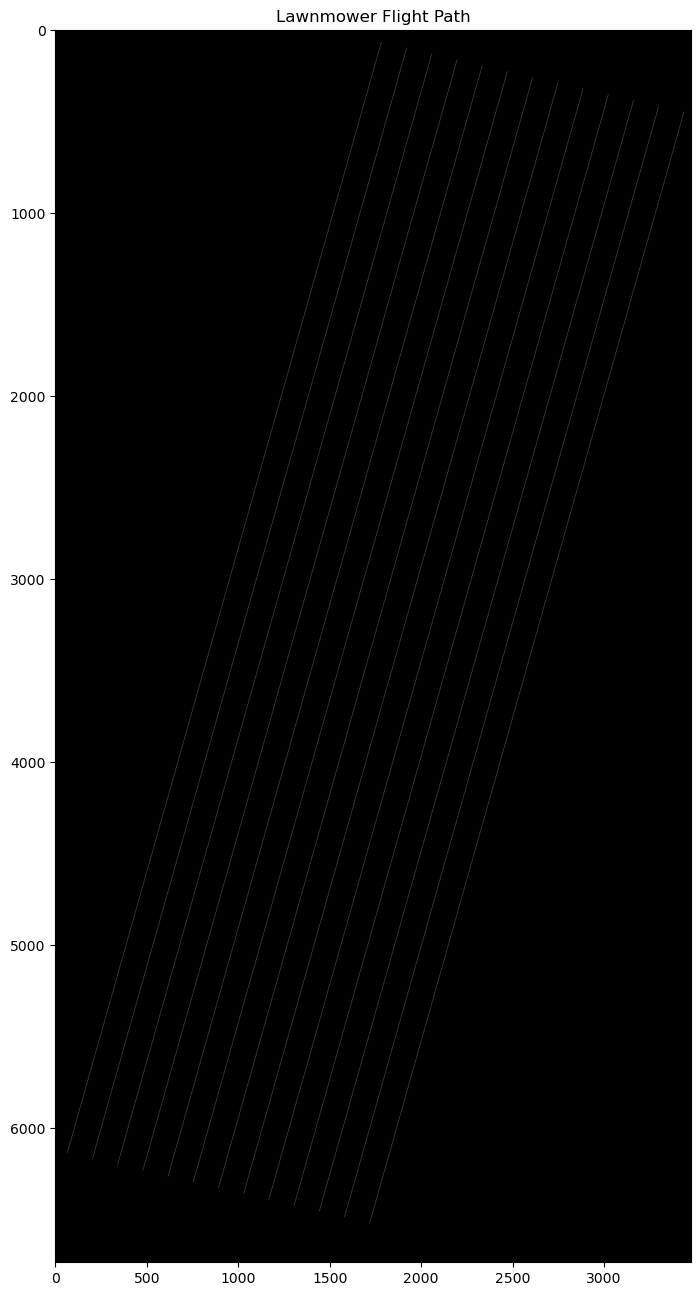

In [3]:
lawnmower_path = np.zeros_like(gu.ndvi)
lawnmower_path_wp = list()

for i in range(lawnmower_num_steps + 1):
    offset = unit_step * (i * lawnmower_step_size)
    start = p0 + offset
    end = p1 + offset

    sweep_length = np.linalg.norm(end - start)
    num_chunks_along = int(sweep_length // gu.CHUNK_DIM_PX)
    
    if i % 2 == 0:
        direction = 1
    else:
        direction = -1

    prev_point = None
    for j in range(num_chunks_along + 1):
        t = j / num_chunks_along if direction == 1 else 1 - (j / num_chunks_along)
        point = start * (1 - t) + end * t
        y, x = int(round(point[0])), int(round(point[1]))

        if t==0 or t==1:
            lawnmower_path_wp.append(gu.pixel_coord_to_geo_coord(y, x))

        if prev_point is not None:
            rr, cc = line(prev_point[0], prev_point[1], y, x)
            rr = np.clip(rr, 0, lawnmower_path.shape[0] - 1)
            cc = np.clip(cc, 0, lawnmower_path.shape[1] - 1)
            lawnmower_path[rr, cc] = 1
        else:
            if 0 <= y < lawnmower_path.shape[0] and 0 <= x < lawnmower_path.shape[1]:
                lawnmower_path[y, x] = 1

        prev_point = (y, x)

plt.figure(figsize=(10,16))
plt.imshow(lawnmower_path, cmap="gray")
plt.title("Lawnmower Flight Path")
plt.show()

In [4]:
os.makedirs(os.path.dirname("Flight Paths/lawnmower.npy"), exist_ok=True)

np.save("Flight Paths/lawnmower.npy", lawnmower_path)

with open("Flight Paths/lawnmower.json", "w") as f:
    json.dump(lawnmower_path_wp, f, indent=4)

gu.generate_mission_waypoints(lawnmower_path_wp, "Flight Paths/lawnmower.waypoints")

# Greedy Algorithm (Nearest Neighbour First)

In [5]:
with open("Data/infected.json") as f:
    infected_json = json.load(f)

infected_points = [gu.chunk_coord_to_pixel_coord(point["chunk_index"][0], point["chunk_index"][1]) for point in infected_json]
infected_tree = KDTree(np.array(infected_points))

In [6]:
visited = [False] * len(infected_points)
current = np.floor(p0).astype(int)
path = [current]
current_idx = None
num_infected = len(infected_points)

while len(path) <num_infected + 1:
    dist, idx = infected_tree.query(current, k=num_infected)

    next_idx = None
    for I in idx:
        if not visited[I]:
            visited[I] = True
            next_idx = I
            break

    if next_idx is None:
        print(f"No connected nodes found at {current}")
        break

    path.append(infected_points[next_idx])
    current = infected_points[next_idx]

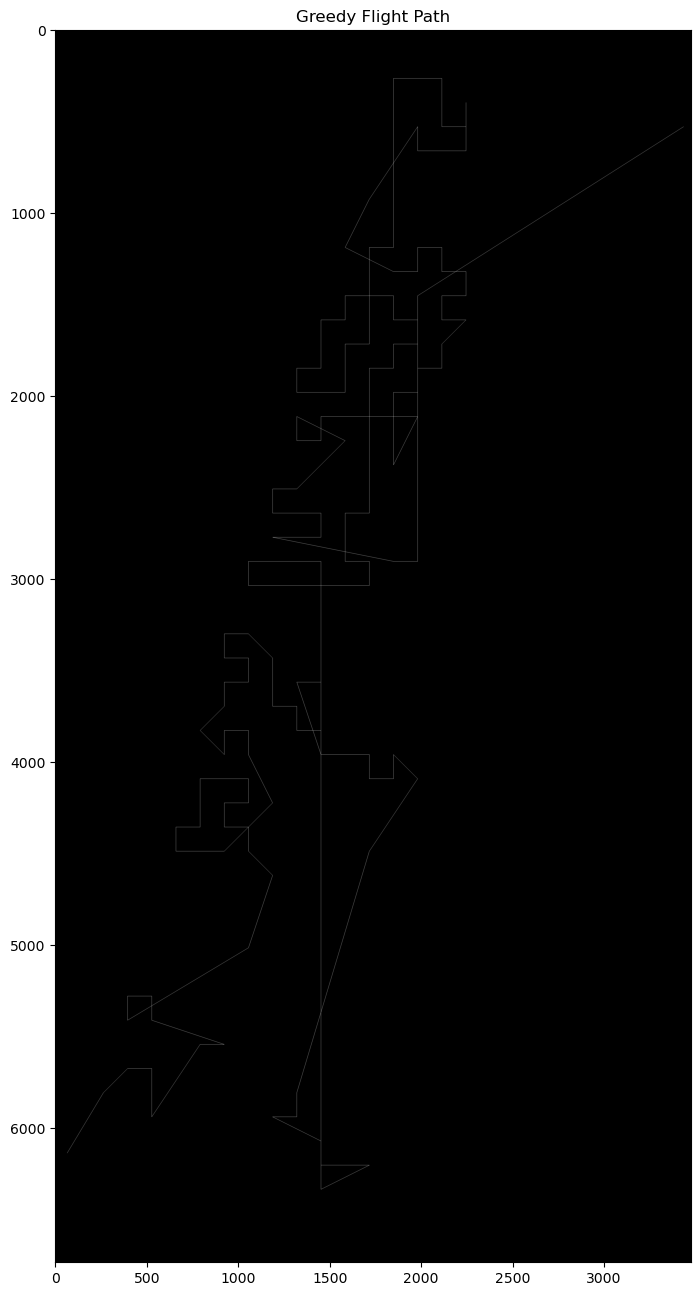

In [7]:
greedy_path = np.zeros_like(gu.ndvi)

for i in range(len(path) - 1):
    start = path[i]
    end = path[i+1]

    rr, cc = line(start[0], start[1], end[0], end[1])

    greedy_path[rr, cc] = 1

plt.figure(figsize=(10,16))
plt.imshow(greedy_path, cmap="gray")
plt.title("Greedy Flight Path")
plt.show()

In [8]:
os.makedirs(os.path.dirname("Flight Paths/greedy.npy"), exist_ok=True)
np.save("Flight Paths/greedy.npy", greedy_path)

# Heading-weighted Greedy (K-Nearest Neighbours)

The greedy generated path includes lots of 90-degree sharp turns which are not ideal for drone flight, so we make a Heading-weighted Greedy (HWG) algorithm which selects the next point based on Time to reach from K-Nearest Neighbours